## Set root

In [2]:
import pyrootutils
from pathlib import Path
import os

filepath = Path.cwd()
root = pyrootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)
root_mnist = root / "mnist"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load data module and predictions
Then the predictions are loaded into the data module. These will be packaged together with the other data samples.

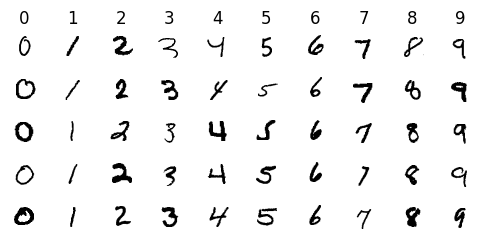

In [3]:
import numpy as np
from mnist.modules.keras_mnist_datamodule import MNISTDataModule

data_module = MNISTDataModule(
    data_dir=root_mnist / "metadata/data"
).from_joblib()

data_module.plot_samples()

# Load prediction model
You can choose between an MLP and a CNN.

In [4]:
from keras.models import load_model

model = load_model(root_mnist / "metadata/model")

model.summary()



Model: "mlp"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               200960    
                                                                 
 dense_1 (Dense)             (None, 128)               32896     
                                                                 
 dense_2 (Dense)             (None, 10)                1290      
                                                                 
Total params: 235146 (918.54 KB)
Trainable params: 235146 (918.54 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


## Instantiate the model module.
The model module acts as a translator between the model and safetycage, translating the syntax of the model to something standardize that the safetycage can use, for all models.

In [5]:
from mnist.modules.keras_modelmodule import KerasModelModule

model_module = KerasModelModule(
    model=model, selected_layers=["dense_2"], use_onehot_encoder=True
)

In [6]:
inputs_train, labels_train = data_module.data_train

predictions_train = model_module._get_predictions(inputs_train)

1500/1500 [==============================] - 2s 1ms/step


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

accuracy = accuracy_score(labels_train, predictions_train)
precision = precision_score(labels_train, predictions_train, average="weighted")
recall = recall_score(labels_train, predictions_train, average="weighted")

print("Performance on training data:")
print(f"Accuracy: {accuracy * 100:.4f} %")
print(f"Precision: {precision * 100:.4f} %")
print(f"Recall: {recall * 100:.4f} %")

Performance on training data:
Accuracy: 97.4437 %
Precision: 97.4441 %
Recall: 97.4437 %


## Instantiate a safetycage

In [8]:
from safetycage.methods.spardacus import SPARDACUS

safetycage = SPARDACUS(
    model_module, data_module,
    s_statistic_source="correctly",
    test_type_between_layers="cauchy",
    cauchy_weights_per_layer=[],
    minimum_sample_size=3) 

## Train the safetycage

In [9]:
# Train the safety cage on training data
# safetycage.train_cage(x=inputs_train, y=labels_train, y_pred=predictions_train)
safetycage.train_cage()

1500/1500 [==============================] - 2s 1ms/step


100%|██████████| 10/10 [00:14<00:00,  1.43s/it]


## Safetycage predicts on validation data
Safetycage predicts whether samples have been misclassified by classifier. The type of statistic will vary depending on the safetycage method, but will say something about how likely it is a given sample has been misclassified.

In [10]:
inputs_val, labels_val = data_module.data_val

predictions_val = model_module._get_predictions(inputs_val)
incorrect_predictions_val = ~(
    np.argmax(predictions_val, axis=1) == np.argmax(labels_val, axis=1)
)

max_probs_val = safetycage.predict(
    x=inputs_val,
    y=predictions_val,
)

375/375 [==============================] - 1s 2ms/step


## Find threshold that maximizes a performance metric
Use the statistics from the validation data produced by the safetycage, to find a theshold that will maximize a metric, when compared to the ground truth (correct or incorrect classification)


In [11]:
from safetycage.utils.evaluate import find_best_threshold, MCC, accuracy

metric = MCC

# Find optimal alpha for specified max metric based on the validation data
optimisation_result = find_best_threshold(
    y_probs=max_probs_val,
    y_true=incorrect_predictions_val,
    metric_fn=metric,
    greater_is_better=True,
)

threshold_val = optimisation_result["alpha_opt"]
metric_val = optimisation_result["metric_max"]

print("\nOptimal threshold and performance metric based on validation data:")
print(f"Threshold = {threshold_val:.4f}")
print(f"{metric.__name__} = {metric_val:.4f}")

safetycage.alpha = threshold_val
safetycage.threshold_metric_val = metric_val

threshold_flag_result = safetycage.find_best_threshold_flag(
    y_probs=max_probs_val,
    y_true=incorrect_predictions_val,
    metric_fn=metric
)

print("\nOptimal threshold and performance metric using safetycage.flag() based on validation data:")
print(f"Flag Threshold = {threshold_flag_result['alpha_opt']:.4f}")
print(f"{metric.__name__} = {threshold_flag_result['metric_max']:.4f}")

print(f"\nThresholds Difference = {optimisation_result['alpha_opt'] - threshold_flag_result['alpha_opt']:.4f}")
print(f"Metric Difference = {optimisation_result['metric_max'] - threshold_flag_result['metric_max']:.4f}")


Optimal threshold and performance metric based on validation data:
Threshold = 0.0441
MCC = 0.4849

Optimal threshold and performance metric using safetycage.flag() based on validation data:
Flag Threshold = 0.0440
MCC = 0.4834

Thresholds Difference = 0.0000
Metric Difference = 0.0015


## Test with optimal threshold, the performance on the test data partition.
Finally we test the safetycage with the inferred threshold parameter, on a hold out test data set. The flags are the predicitons made by the safetycage.

In [12]:
inputs_test, labels_test = data_module.data_test

prediction_test = model_module._get_predictions(inputs_test)
incorrect_prediction_test = ~(
    np.argmax(prediction_test, axis=1) == np.argmax(labels_test, axis=1)
)

max_probs_test = safetycage.predict(
    x=inputs_test,
    y=prediction_test,
)

flags_test = safetycage.flag(max_probs_test)

313/313 [==============================] - 0s 1ms/step


# Calculate metrics of the predictions on the test data set.
Compute a set of metrics that will inform us of the safetycages abillity to flag misclassification made by a certain model on a certain dataset.

In [13]:
import json

from safetycage.utils.evaluate import (
    calculate_confusion_rates,
    calculate_metrics,
    calculate_auroc,
)

# Calculate confusion rates and metrics based on test data
confusion_rates_test = calculate_confusion_rates(
    y=incorrect_prediction_test,
    y_pred=flags_test,
)

# Calculate AUROC based on test data
auroc_test = calculate_auroc(
    safetycage=safetycage,
    y_true=incorrect_prediction_test,
    y_scores=max_probs_test,  # Assuming the first column contains the scores
)

# Calculate metrics based on test data
metrics_test = calculate_metrics(y=incorrect_prediction_test, y_pred=flags_test)

# Add confusion rates and AUROC to metrics dictionary
metrics_test.update(confusion_rates_test)
metrics_test.update({"AUROC": auroc_test})

os.makedirs("./results", exist_ok=True)
with open("./results/metrics_test.json", "w") as f:
    json.dump(metrics_test, f, indent=4)

for name, value in metrics_test.items():
    print(f"{name}: {value:.4f}")

Precision: 0.3928
Recall: 0.6301
Specificity: 0.9651
NPV: 0.9864
MCC: 0.4751
Accuracy: 0.9535
F1-score: 0.4839
TP: 218.0000
TN: 9317.0000
FP: 337.0000
FN: 128.0000
AUROC: 0.9501


## Plots
Further we plot a number of figures showing further the performance of safetycage. These plots are the 
1. Confusion matrix, 
2. Threshold-metric curve (how the  metric varies with the threshold)
3. Reciever-operator curve.

In [14]:
from safetycage.utils.evaluate import calculate_roc_curve

from safetycage.utils.plot_functions import (
    plot_alpha_metric_curve,
    plot_confusion_matrix,
    plot_roc_curve,
)

best_metric_dict = find_best_threshold(
    y_probs=max_probs_test,
    y_true=incorrect_prediction_test,
    metric_fn=metric,
    greater_is_better=True,
)

# plots
plot_alpha_metric_curve(
    **best_metric_dict,
    thresholds=optimisation_result["alphas"],
    scores=optimisation_result["metric_values"],
    output_path="./results",
    alpha_val=safetycage.alpha,
    metric_val=safetycage.threshold_metric_val,
    val_label_offset=(0.0, 0.10) # the validation label tends to cover the data
)


plot_confusion_matrix(
    y_true=incorrect_prediction_test,
    y_pred=flags_test,
    normalize=None,
    output_path="./results",
)

roc = calculate_roc_curve(
    safetycage=safetycage,
    y_true=incorrect_prediction_test,
    statistics=max_probs_test,
    num_thresholds=1e4,
)

plot_roc_curve(
    **roc,
    output_path="./results"
)

In [15]:
safetycage.save_cage("./saved_cage")

In [16]:
safetycage.alpha = None
safetycage.layer_params = None

safetycage.load_cage("./saved_cage")

print(safetycage.alpha)
print(safetycage.layer_params)

0.04406100000000002
{'dense_2': {0: {}, 1: {}, 2: {}, 3: {}, 4: {}, 5: {}, 6: {}, 7: {}, 8: {}, 9: {}, '0': {'ecdf_correct': <statsmodels.distributions.empirical_distribution.ECDF object at 0x000002466F1E1FD0>, 'ecdf_incorrect': None, 'beta_hat': array([ 0.92027902, -0.01550638, -0.06246743, -0.03554661, -0.08554028,
       -0.07929492, -0.22687605, -0.05809973, -0.26659046, -0.0903145 ]), 'density_correct': GaussianMixture(n_components=3), 'density_incorrect': GaussianMixture()}, '1': {'ecdf_correct': <statsmodels.distributions.empirical_distribution.ECDF object at 0x000002466EE19550>, 'ecdf_incorrect': None, 'beta_hat': array([ 0.01549876, -0.92717276,  0.21497031,  0.11146429,  0.0946006 ,
        0.03731725,  0.03753666,  0.12085395,  0.22374469,  0.07110355]), 'density_correct': GaussianMixture(n_components=3), 'density_incorrect': GaussianMixture()}, '2': {'ecdf_correct': <statsmodels.distributions.empirical_distribution.ECDF object at 0x000002466ED13D90>, 'ecdf_incorrect': None,